## Imports

In [3]:
import json
import sys
import os

# שינוי לתיקייה הראשית של הפרויקט
os.chdir(os.path.dirname(os.path.abspath('.')))
project_root = os.path.abspath('.')
sys.path.append(project_root)
print(f"Working directory: {os.getcwd()}")

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from app.modules.main_agent import get_main_agent_response
from app.modules.scheduling_advisor import init_db

init_db()
print("✅ Ready")

Working directory: c:\Users\User\Downloads\GAI Project
✅ Database initialized successfully
✅ Ready


## טעינת נתוני הבדיקה

In [4]:
with open("data/sms_conversations.json", "r") as f:
    conversations = json.load(f)

# בונה רשימת test cases מהשיחות
test_cases = []

for conv in conversations:
    turns = conv["turns"]
    chat_history = []
    
    for i, turn in enumerate(turns):
        if turn["speaker"] == "recruiter" and turn["label"] in ["end", "continue", "schedule"]:
            test_cases.append({
                "message": turn["text"],
                "true_label": turn["label"],
                "history": chat_history.copy()
            })
        
        # בונה היסטוריה
        if turn["speaker"] == "recruiter":
            chat_history.append({"role": "assistant", "content": turn["text"]})
        else:
            chat_history.append({"role": "user", "content": turn["text"]})

print(f"✅ Loaded {len(test_cases)} test cases")
print(f"Label distribution:")
from collections import Counter
labels = [t["true_label"] for t in test_cases]
print(Counter(labels))

✅ Loaded 59 test cases
Label distribution:
Counter({'continue': 25, 'schedule': 19, 'end': 15})


## הרצת המודל על כל הנתונים

In [5]:
results = []

for i, case in enumerate(test_cases):
    print(f"Testing case {i+1}/{len(test_cases)}...", end="\r")
    
    try:
        result = get_main_agent_response(
            case["history"],
            case["message"]
        )
        predicted = result["decision"]
    except Exception as e:
        predicted = "continue"  # default במקרה של שגיאה
    
    results.append({
        "message": case["message"][:50],
        "true_label": case["true_label"],
        "predicted": predicted,
        "correct": case["true_label"] == predicted
    })

print(f"\n✅ Done! Tested {len(results)} cases")

🚪 Exit Advisor decision: continue
🤖 Main Agent decision: continue
🚪 Exit Advisor decision: continue
🤖 Main Agent decision: schedule
🚪 Exit Advisor decision: continue
🤖 Main Agent decision: schedule
🚪 Exit Advisor decision: end
🚪 Exit Advisor decision: continue
🤖 Main Agent decision: continue
🚪 Exit Advisor decision: continue
🤖 Main Agent decision: continue
🚪 Exit Advisor decision: continue
🤖 Main Agent decision: schedule
🚪 Exit Advisor decision: continue
🤖 Main Agent decision: schedule
🚪 Exit Advisor decision: end
🚪 Exit Advisor decision: continue
🤖 Main Agent decision: continue
🚪 Exit Advisor decision: continue
🤖 Main Agent decision: continue
🚪 Exit Advisor decision: continue
🤖 Main Agent decision: continue
🚪 Exit Advisor decision: end
🚪 Exit Advisor decision: continue
🤖 Main Agent decision: continue
🚪 Exit Advisor decision: continue
🤖 Main Agent decision: continue
🚪 Exit Advisor decision: continue
🤖 Main Agent decision: schedule
🚪 Exit Advisor decision: end
🚪 Exit Advisor decision: c

## חישוב Accuracy

In [6]:
df = pd.DataFrame(results)

true_labels = df["true_label"].tolist()
pred_labels = df["predicted"].tolist()

accuracy = accuracy_score(true_labels, pred_labels)

print(f"📊 Overall Accuracy: {accuracy:.2%}")
print(f"\nResults breakdown:")
print(df.groupby(["true_label", "predicted"]).size().unstack(fill_value=0))

📊 Overall Accuracy: 94.92%

Results breakdown:
predicted   continue  end  schedule
true_label                         
continue          23    0         2
end                0   15         0
schedule           1    0        18


## Confusion Matrix

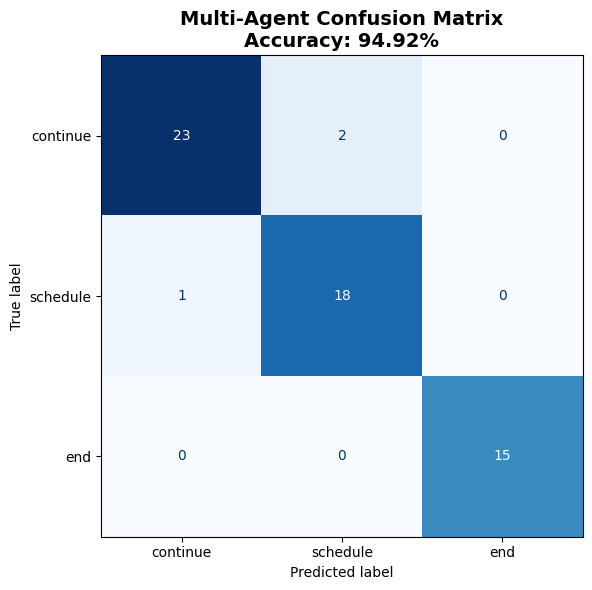

✅ Saved to tests/confusion_matrix.png


In [7]:
labels_order = ["continue", "schedule", "end"]

cm = confusion_matrix(true_labels, pred_labels, labels=labels_order)

fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels_order)
disp.plot(ax=ax, cmap="Blues", colorbar=False)

ax.set_title(f"Multi-Agent Confusion Matrix\nAccuracy: {accuracy:.2%}", 
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("tests/confusion_matrix.png", dpi=150)
plt.show()
print("✅ Saved to tests/confusion_matrix.png")

## ניתוח שגיאות

In [8]:
errors = df[df["correct"] == False]

print(f"❌ Total errors: {len(errors)}/{len(df)}")
print(f"\nError cases:")
for _, row in errors.iterrows():
    print(f"\nMessage: {row['message']}")
    print(f"True: {row['true_label']} | Predicted: {row['predicted']}")

❌ Total errors: 3/59

Error cases:

Message: We currently deploy to AWS using Docker and ECS.
True: continue | Predicted: schedule

Message: Hybrid work model, with at least two days of remot
True: continue | Predicted: schedule

Message: Alright, would Wednesday at 1 PM work?
True: schedule | Predicted: continue
